# 211 — MHC ortholog recovery and AUC, by alphabet and k-size

**Question:** which alphabet × k-size combination detects human→mouse MHC orthologs, and how much
does that answer depend on the label policy?

Genome-wide F1 (notebook
[200](./200_human_mouse_ortholog_alphabet_ksize_comparison.ipynb)) is dominated by high-identity
orthologs and says nothing about the hardest case. MHC is that case: kmerseek's weakest structural
class (the antigen-recognition domain is an open β-sheet plus α-helix) and the most polymorphic gene
family in the genome. This notebook re-scores the same 25-gene query against every combo 200 has
validated, and asks whether the genome-wide ranking survives.

Everything here reads [210](./210_mhc_benchmark_setup_and_label_policy.ipynb)'s pair table; no
ground truth is rebuilt. Every AUC is computed under all three of 210's label policies, with
`synteny_nearest` as the headline — the only one under which a class I number is comparable to a
class II number. Where the three disagree, that disagreement *is* the result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.metrics import average_precision_score, roc_auc_score

import ortholog_analysis_utils as ou

RES = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
FIG_DIR = Path("../figures")

pair = pl.read_parquet(RES / "210_mhc_pair_table.parquet")
MHC_CLASSES, CLASS_ORDER = ou.MHC_CLASSES, ou.MHC_CLASS_ORDER

combos_df = ou.load_all_alphabet_ksize_combos().filter(pl.col("dash_encoding") != "hp")
ALPHABET_DISPLAY_NAMES = dict(
    zip(combos_df["dash_encoding"].to_list(), combos_df["display_encoding"].to_list())
)
COMBOS = [
    (e, k)
    for e, k in zip(combos_df["dash_encoding"].to_list(), combos_df["ksize"].to_list())
]
ALPHABET_CMAPS, _ = ou.alphabet_combo_colors(COMBOS, ALPHABET_DISPLAY_NAMES)

# Combos are identified by the display label the pair table already carries, so this notebook can
# never disagree with 210 about which combo a row belongs to.
SCORED = pair["combo"].unique().to_list()
alphabets_present = sorted(
    pair["encoding"].unique().to_list(), key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e)
)
alphabet_color = {e: plt.get_cmap(ALPHABET_CMAPS[e])(0.6) for e in alphabets_present}
ks_by_alphabet = {
    e: sorted(pair.filter(pl.col("encoding") == e)["ksize"].unique().to_list())
    for e in alphabets_present
}

print(
    f"{len(SCORED)} scored combos across {len(alphabets_present)} alphabets, "
    f"{len(pair):,} candidate pairs"
)
print(f"label policies carried: {[c for c in pair.columns if c.startswith('label_')]}")

76 scored combos across 8 alphabets, 1,256,268 candidate pairs
label policies carried: ['label_any_member', 'label_synteny_nearest', 'label_best_scoring_member']


## 1. AUC per combo, per class, under all three policies

Two groups are scored: **class I** (the six heavy chains A/B/C/E/F/G) and **class II** (α + β). For
each, ROC-AUC and average precision are computed under each label policy, alongside the positive
count and the prevalence, since an average precision without its baseline is unreadable (210 §4).

Combos where a group has no positives, or no negatives, under a given policy are skipped rather than
scored as 0: an AUC is undefined there.

In [2]:
GROUPS = {
    "class I (A/B/C/E/F/G)": pl.col("mhc_class").str.starts_with("I ")
    & ~pl.col("mhc_class").str.contains("MIC"),
    "class II (α+β)": pl.col("mhc_class").str.starts_with("II"),
}

rows = []
for combo in SCORED:
    sub_all = pair.filter(pl.col("combo") == combo)
    for gname, expr in GROUPS.items():
        sub = sub_all.filter(expr)
        if sub.height == 0:
            continue
        s = sub["containment"].to_numpy()
        for policy, col in ou.LABEL_POLICY_COLS.items():
            y = sub[col].to_numpy().astype(int)
            if y.sum() == 0 or y.sum() == len(y):
                continue  # AUC undefined; skipped rather than imputed
            rows.append(
                {
                    "combo": combo,
                    "encoding": sub["encoding"][0],
                    "ksize": sub["ksize"][0],
                    "group": gname,
                    "policy": policy,
                    "roc_auc": roc_auc_score(y, s),
                    "pr_auc": average_precision_score(y, s),
                    "n_pos": int(y.sum()),
                    "n": len(y),
                    "prevalence": float(y.mean()),
                }
            )
auc_df = pl.DataFrame(rows)
print(f"{auc_df.height:,} (combo, group, policy) AUC rows")

summary = (
    auc_df.group_by(["group", "policy"])
    .agg(
        [
            pl.len().alias("n_combos"),
            pl.col("roc_auc").median().round(3).alias("median_roc"),
            pl.col("roc_auc").max().round(3).alias("best_roc"),
            pl.col("pr_auc").median().round(3).alias("median_pr"),
            pl.col("prevalence").median().round(4).alias("median_baseline"),
        ]
    )
    .sort(["group", "policy"])
)
print(summary)

print(
    "\nBest combo per (group, policy) -- note how the headline combo can change with the policy:"
)
best = (
    auc_df.sort("roc_auc", descending=True)
    .group_by(["group", "policy"], maintain_order=True)
    .first()
    .select(["group", "policy", "combo", "roc_auc", "pr_auc", "n_pos", "prevalence"])
)
print(best.sort(["group", "policy"]))

445 (combo, group, policy) AUC rows
shape: (6, 7)
┌─────────────────┬────────────────┬──────────┬────────────┬──────────┬───────────┬────────────────┐
│ group           ┆ policy         ┆ n_combos ┆ median_roc ┆ best_roc ┆ median_pr ┆ median_baselin │
│ ---             ┆ ---            ┆ ---      ┆ ---        ┆ ---      ┆ ---       ┆ e              │
│ str             ┆ str            ┆ u32      ┆ f64        ┆ f64      ┆ f64       ┆ ---            │
│                 ┆                ┆          ┆            ┆          ┆           ┆ f64            │
╞═════════════════╪════════════════╪══════════╪════════════╪══════════╪═══════════╪════════════════╡
│ class I         ┆ any_member     ┆ 76       ┆ 0.727      ┆ 0.999    ┆ 0.19      ┆ 0.0491         │
│ (A/B/C/E/F/G)   ┆                ┆          ┆            ┆          ┆           ┆                │
│ class I         ┆ best_scoring_m ┆ 76       ┆ 0.957      ┆ 1.0      ┆ 0.189     ┆ 0.0078         │
│ (A/B/C/E/F/G)   ┆ ember          ┆     

class I ROC-AUC, synteny_nearest minus any_member, across 65 combos:
  median -0.020 | IQR -0.137 to +0.017 | range -0.465 to +0.454
  combos where the policy flips the verdict across ROC-AUC 0.5: 18/65


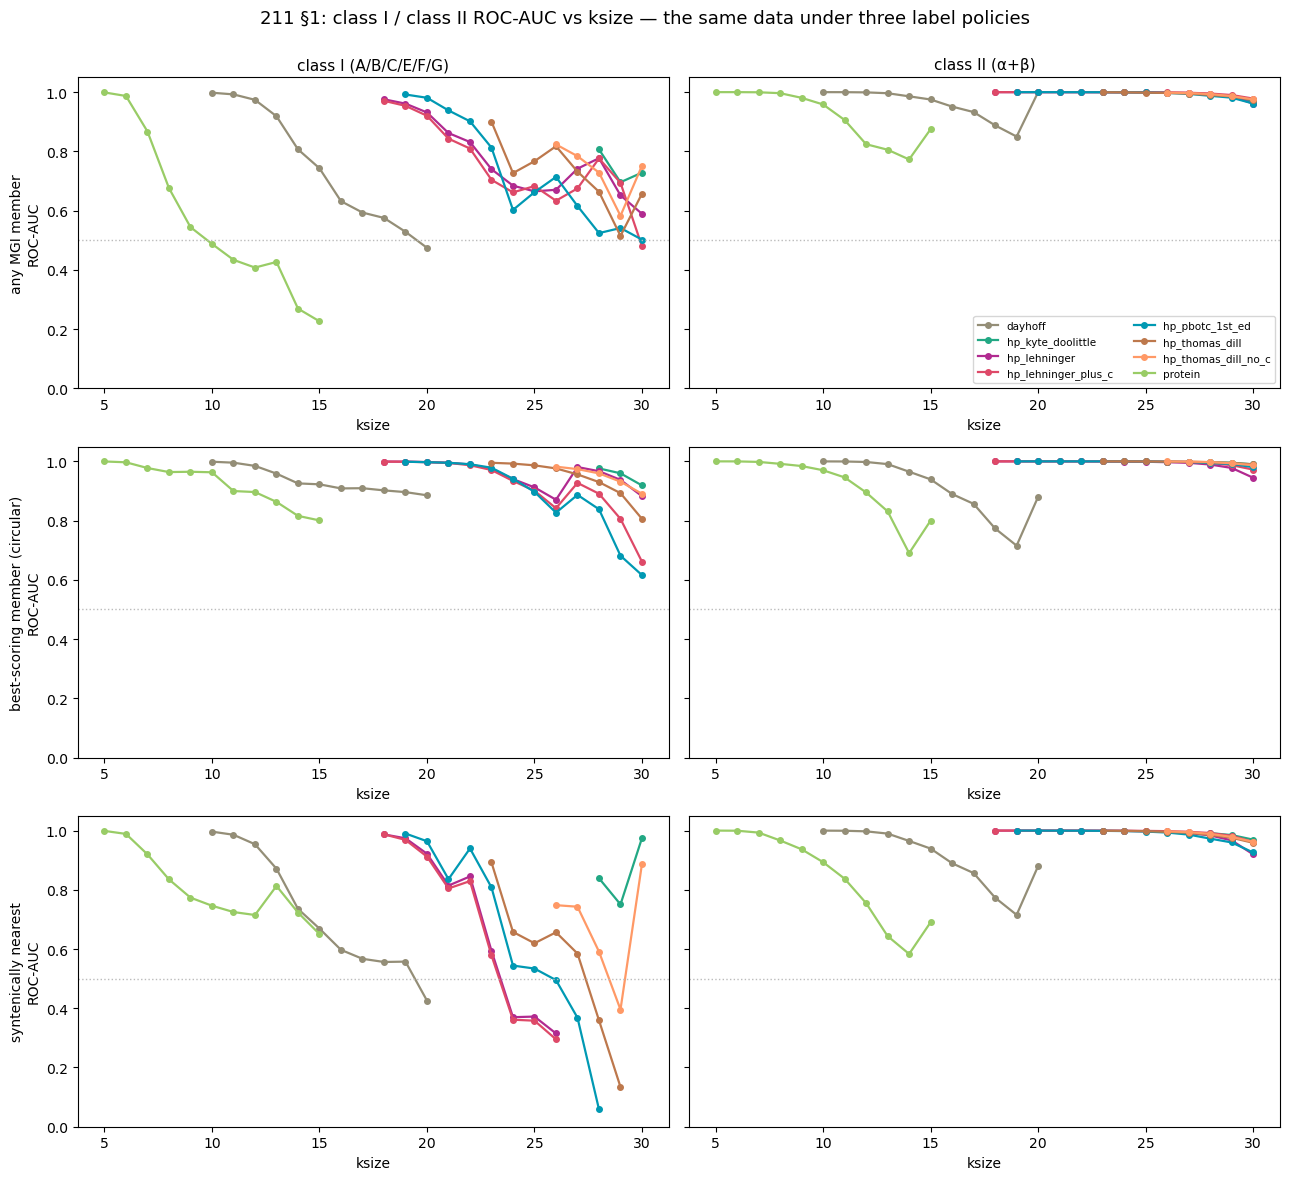

In [3]:
# Figure: ROC-AUC vs ksize, one row per label policy, one column per class group, one line per
# alphabet. The policy is a ROW rather than a separate figure so the reader cannot compare a class I
# number from one policy against a class II number from another without noticing.
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharey=True, sharex=False)
for r, policy in enumerate(ou.LABEL_POLICIES):
    for c, gname in enumerate(GROUPS):
        ax = axes[r, c]
        sub_p = auc_df.filter((pl.col("policy") == policy) & (pl.col("group") == gname))
        for enc in alphabets_present:
            s = sub_p.filter(pl.col("encoding") == enc).sort("ksize")
            if s.height == 0:
                continue
            ax.plot(
                s["ksize"],
                s["roc_auc"],
                "o-",
                color=alphabet_color[enc],
                lw=1.6,
                ms=4,
                label=ALPHABET_DISPLAY_NAMES.get(enc, enc),
            )
        ax.axhline(0.5, color="#bbb", ls=":", lw=1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("ksize")
        if c == 0:
            ax.set_ylabel(f"{ou.LABEL_POLICY_LABELS[policy]}\nROC-AUC")
        if r == 0:
            ax.set_title(gname, fontsize=11)
axes[0, 1].legend(fontsize=7.5, loc="lower right", ncol=2)
fig.suptitle(
    "211 §1: class I / class II ROC-AUC vs ksize — the same data under three label policies",
    fontsize=13,
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIG_DIR / "211_auc_vs_ksize_by_policy.png", dpi=150, bbox_inches="tight")

# How much does the policy move class I? Paired per combo, so this is a like-for-like delta.
wide = auc_df.filter(pl.col("group") == "class I (A/B/C/E/F/G)").pivot(
    index="combo", on="policy", values="roc_auc"
)
have = [p for p in ou.LABEL_POLICIES if p in wide.columns]
if {"any_member", "synteny_nearest"} <= set(have):
    d = wide.drop_nulls(["any_member", "synteny_nearest"])
    delta = d["synteny_nearest"] - d["any_member"]
    print(
        f"class I ROC-AUC, synteny_nearest minus any_member, across {d.height} combos:"
    )
    print(
        f"  median {delta.median():+.3f} | IQR {delta.quantile(0.25):+.3f} to {delta.quantile(0.75):+.3f} "
        f"| range {delta.min():+.3f} to {delta.max():+.3f}"
    )
    print(
        f"  combos where the policy flips the verdict across ROC-AUC 0.5: "
        f"{int(((d['any_member'] > 0.5) != (d['synteny_nearest'] > 0.5)).sum())}/{d.height}"
    )

## 2. Ortholog recovery: where does the true partner rank?

AUC pools every candidate pair. Recovery asks the operational question: for each human gene, rank
its mouse hits by containment and check whether the true partner comes out on top. `recovery@1` and
`recovery@5` are the fraction of genes whose true partner is the top or top-5 hit.

Under `any_member` this asks whether *any* MGI partner ranked first, which for a 15-partner class I
gene is easier than the same question for a 1:1 class II gene. Under `synteny_nearest` it is the
same task for both. Both are shown.

recovery@1 by class and policy (median across combos):
shape: (21, 4)
┌───────────────────┬─────────────────────┬───────────────────┬────────────────┐
│ class             ┆ policy              ┆ median_recovery@1 ┆ median_n_genes │
│ ---               ┆ ---                 ┆ ---               ┆ ---            │
│ str               ┆ str                 ┆ f64               ┆ f64            │
╞═══════════════════╪═════════════════════╪═══════════════════╪════════════════╡
│ I classical       ┆ any_member          ┆ 0.333             ┆ 3.0            │
│ I classical       ┆ best_scoring_member ┆ 0.333             ┆ 3.0            │
│ I classical       ┆ synteny_nearest     ┆ 0.0               ┆ 2.0            │
│ I non-classical   ┆ any_member          ┆ 0.0               ┆ 3.0            │
│ I non-classical   ┆ best_scoring_member ┆ 0.0               ┆ 3.0            │
│ …                 ┆ …                   ┆ …                 ┆ …              │
│ light chain       ┆ best_scoring_memb

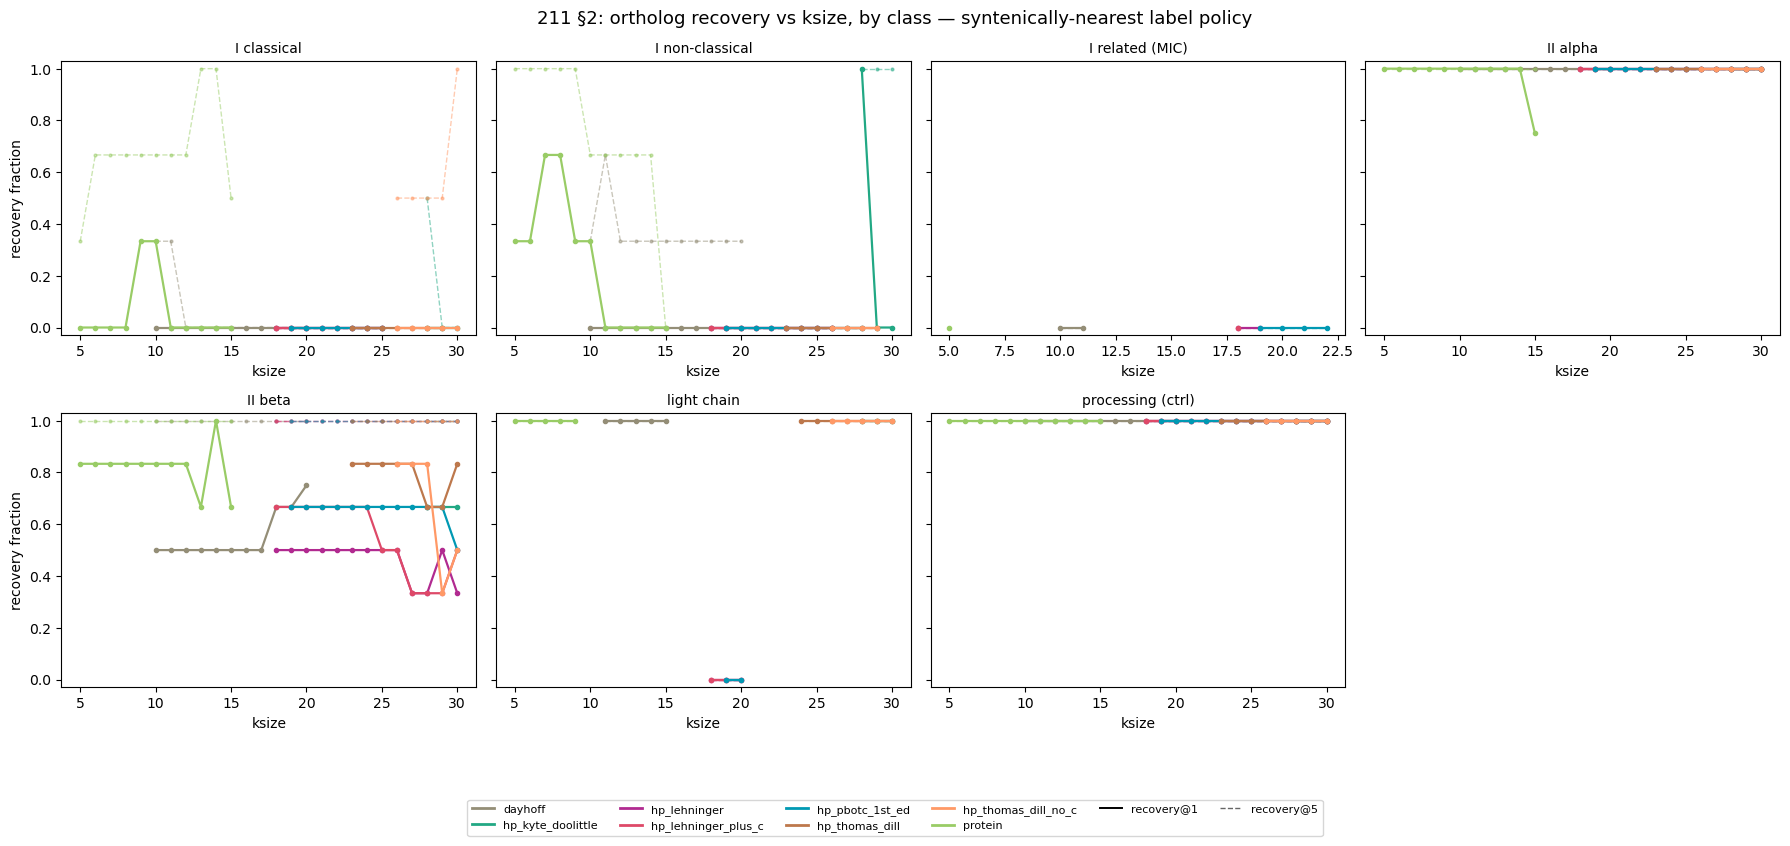

In [4]:
def recovery(sub: pl.DataFrame, label_col: str) -> dict:
    """recovery@1 / @5 / median rank of the best true partner, over genes that have one."""
    r1 = r5 = n = 0
    ranks = []
    for _, g in sub.group_by("human_gene"):
        g = g.sort("containment", descending=True)
        hits = [i + 1 for i, v in enumerate(g[label_col].to_list()) if v]
        if not hits:
            continue  # gene has no positive under this policy: not a miss, out of scope
        n += 1
        best = min(hits)
        ranks.append(best)
        r1 += best == 1
        r5 += best <= 5
    return {
        "n_genes": n,
        "recovery@1": r1 / n if n else np.nan,
        "recovery@5": r5 / n if n else np.nan,
        "median_rank": float(np.median(ranks)) if ranks else np.nan,
    }


rec_rows = []
for combo in SCORED:
    sub_all = pair.filter(pl.col("combo") == combo)
    for cls in CLASS_ORDER:
        sub = sub_all.filter(pl.col("mhc_class") == cls)
        if sub.height == 0:
            continue
        for policy, col in ou.LABEL_POLICY_COLS.items():
            rec_rows.append(
                {
                    "combo": combo,
                    "encoding": sub["encoding"][0],
                    "ksize": sub["ksize"][0],
                    "class": cls,
                    "policy": policy,
                    **recovery(sub, col),
                }
            )
rec_df = pl.DataFrame(rec_rows)

print("recovery@1 by class and policy (median across combos):")
print(
    rec_df.group_by(["class", "policy"])
    .agg(
        pl.col("recovery@1").median().round(3).alias("median_recovery@1"),
        pl.col("n_genes").median().alias("median_n_genes"),
    )
    .sort(["class", "policy"])
)

# Figure: recovery@1 vs ksize, one subplot per class, headline policy only (the full 3-policy grid
# is in the AUC figure above; repeating it here would be 21 panels for one extra bit of information).
classes_with_data = [
    c
    for c in CLASS_ORDER
    if rec_df.filter((pl.col("class") == c) & (pl.col("policy") == "synteny_nearest"))[
        "n_genes"
    ].max()
]
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()
for ax, cls in zip(axes, classes_with_data):
    s_cls = rec_df.filter(
        (pl.col("class") == cls) & (pl.col("policy") == "synteny_nearest")
    )
    for enc in alphabets_present:
        s = s_cls.filter(pl.col("encoding") == enc).sort("ksize")
        if s.height == 0:
            continue
        ax.plot(
            s["ksize"],
            s["recovery@1"],
            "o-",
            color=alphabet_color[enc],
            lw=1.6,
            ms=3,
            label=ALPHABET_DISPLAY_NAMES.get(enc, enc),
        )
        ax.plot(
            s["ksize"],
            s["recovery@5"],
            "o--",
            color=alphabet_color[enc],
            lw=1.0,
            ms=2,
            alpha=0.5,
        )
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel("ksize")
    ax.set_ylim(-0.03, 1.03)
for ax in (axes[0], axes[4]):
    ax.set_ylabel("recovery fraction")
for ax in axes[len(classes_with_data) :]:
    ax.axis("off")
handles = [
    plt.Line2D(
        [0], [0], color=alphabet_color[e], lw=2, label=ALPHABET_DISPLAY_NAMES.get(e, e)
    )
    for e in alphabets_present
]
handles += [
    plt.Line2D([0], [0], color="k", lw=1.4, label="recovery@1"),
    plt.Line2D([0], [0], color="k", lw=1.0, ls="--", alpha=0.6, label="recovery@5"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=(len(alphabets_present) + 1) // 2 + 2,
    fontsize=8,
    bbox_to_anchor=(0.5, -0.06),
)
fig.suptitle(
    "211 §2: ortholog recovery vs ksize, by class — syntenically-nearest label policy",
    fontsize=13,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(FIG_DIR / "211_recovery_vs_ksize.png", dpi=150, bbox_inches="tight")

## 3. Putting every alphabet on one scale: empirical bits, not raw k

Section 1's k ranges do not overlap: protein is validated at k=6–15, the HP variants at k=18–30.
Comparing them on raw k mixes a real property of the encoding with a units artifact, since one unit
of k means something different for a 20-symbol alphabet than for a 2-symbol one.

The fix is to compare **k × H**, where H is each alphabet's empirical per-symbol entropy on the real
database. `ou.entropy_per_symbol` computes this from actual amino-acid frequencies counted across
gencode human v49 + mouse vM38, not from a uniform assumption (protein's nominal log2(20) = 4.32
bits overstates it), grouped exactly the way kmerseek groups them at search time (transcribed from
`hp_alphabets.rs`, not reconstructed). The HP alphabets range **0.937–1.000 bits**, not a flat 1.0:
Lehninger lands near a 50/50 split on this database, while kyte_doolittle's 35/65 split costs it
real information per symbol.

alphabet                empirical H  nominal H   (bits/symbol)
protein                      4.1763     4.3219
dayhoff                      2.2780     2.5850
hp_lehninger                 1.0000     1.0000
hp_lehninger_plus_c          0.9991     1.0000
hp_pbotc_1st_ed              0.9938     1.0000
hp_thomas_dill               0.9659     1.0000
hp_thomas_dill_no_c          0.9508     1.0000
hp_kyte_doolittle            0.9370     1.0000

Each alphabet's own best class I point (NOT a matched-budget comparison):
shape: (8, 4)
┌─────────────────────┬───────┬──────┬─────────┐
│ encoding            ┆ ksize ┆ bits ┆ roc_auc │
│ ---                 ┆ ---   ┆ ---  ┆ ---     │
│ str                 ┆ i64   ┆ f64  ┆ f64     │
╞═════════════════════╪═══════╪══════╪═════════╡
│ protein             ┆ 5     ┆ 20.9 ┆ 0.999   │
│ dayhoff             ┆ 10    ┆ 22.8 ┆ 0.996   │
│ hp-pbotc-1st-ed     ┆ 19    ┆ 18.9 ┆ 0.99    │
│ hp-lehninger-plus-c ┆ 18    ┆ 18.0 ┆ 0.987   │
│ hp-lehninger        ┆ 18    ┆

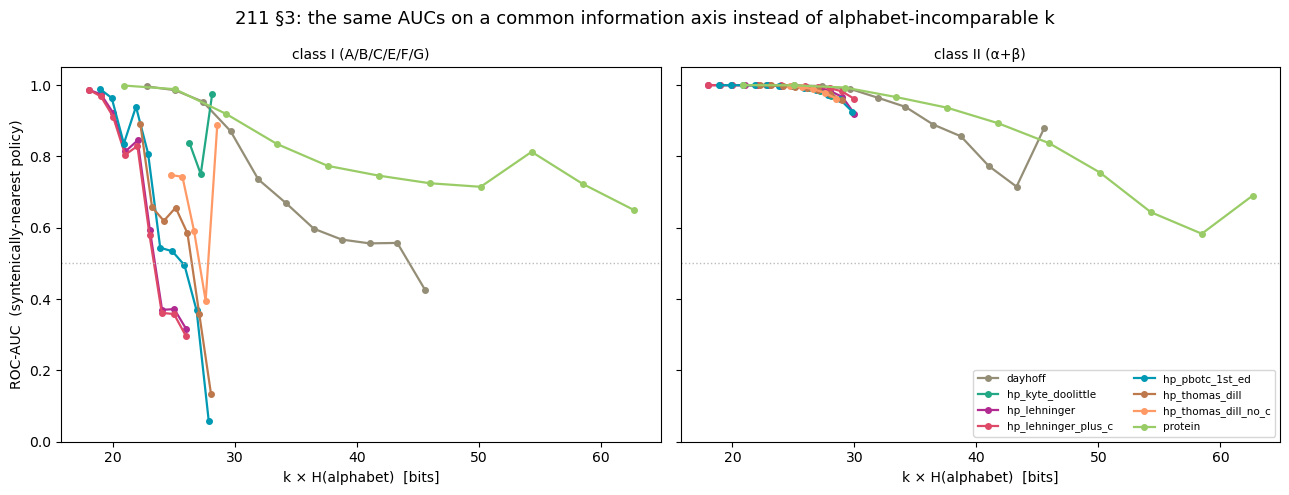

In [5]:
# Entropy comes from ou -- this used to be recomputed inline, which meant the same constant existed
# in two places and could drift. ALPHABET_ENTROPY is keyed by the display name used everywhere else.
ALPHABET_ENTROPY = {
    ALPHABET_DISPLAY_NAMES[e]: ou.entropy_per_symbol(ALPHABET_DISPLAY_NAMES[e])
    for e in alphabets_present
}
print(f"{'alphabet':22s} {'empirical H':>12s} {'nominal H':>10s}   (bits/symbol)")
nominal = {"protein": np.log2(20), "dayhoff": np.log2(6)}
for name, H in sorted(ALPHABET_ENTROPY.items(), key=lambda kv: -kv[1]):
    print(f"{name:22s} {H:12.4f} {nominal.get(name, 1.0):10.4f}")

auc_bits = auc_df.with_columns(
    (
        pl.col("ksize")
        * pl.col("encoding").replace_strict(
            {e: ALPHABET_ENTROPY[ALPHABET_DISPLAY_NAMES[e]] for e in alphabets_present},
            return_dtype=pl.Float64,
        )
    ).alias("bits")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, gname in zip(axes, GROUPS):
    s_g = auc_bits.filter(
        (pl.col("group") == gname) & (pl.col("policy") == "synteny_nearest")
    )
    for enc in alphabets_present:
        s = s_g.filter(pl.col("encoding") == enc).sort("bits")
        if s.height == 0:
            continue
        ax.plot(
            s["bits"],
            s["roc_auc"],
            "o-",
            color=alphabet_color[enc],
            lw=1.6,
            ms=4,
            label=ALPHABET_DISPLAY_NAMES.get(enc, enc),
        )
    ax.axhline(0.5, color="#bbb", ls=":", lw=1)
    ax.set_xlabel("k × H(alphabet)  [bits]")
    ax.set_title(gname, fontsize=10)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("ROC-AUC  (syntenically-nearest policy)")
axes[1].legend(fontsize=7.5, loc="lower right", ncol=2)
fig.suptitle(
    "211 §3: the same AUCs on a common information axis instead of alphabet-incomparable k",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "211_auc_vs_bits.png", dpi=150, bbox_inches="tight")

# The matched-bit-budget comparison, which is the point of the bits axis: each alphabet's own best
# point is NOT an apples-to-apples comparison, because the two peaks sit at different budgets.
ci = auc_bits.filter(
    (pl.col("group") == "class I (A/B/C/E/F/G)")
    & (pl.col("policy") == "synteny_nearest")
)
if ci.height:
    peaks = (
        ci.sort("roc_auc", descending=True)
        .group_by("encoding", maintain_order=True)
        .first()
        .select(["encoding", "ksize", "bits", "roc_auc"])
        .sort("roc_auc", descending=True)
    )
    print("\nEach alphabet's own best class I point (NOT a matched-budget comparison):")
    print(peaks.with_columns(pl.col("bits").round(1), pl.col("roc_auc").round(3)))

    # Matched budget: for the best protein point, find every HP point within +-1.5 bits of it.
    prot = peaks.filter(pl.col("encoding") == "protein")
    if prot.height:
        b0 = prot["bits"][0]
        near = (
            ci.filter((pl.col("bits") - b0).abs() <= 1.5)
            .select(["combo", "bits", "roc_auc"])
            .sort("roc_auc", descending=True)
        )
        print(
            f"\nAt a MATCHED budget of {b0:.1f} ± 1.5 bits (protein's own best), every combo:"
        )
        print(near.with_columns(pl.col("bits").round(1), pl.col("roc_auc").round(3)))

## 4. What the numbers do and do not support

**Read every class I number in this notebook against 210 §5: the effective *n* is 4 lineages, not 6
genes.** The classical trio A/B/C are tips of one recent primate-specific expansion, so they are not
three independent observations. Differences between alphabets on class I smaller than a few tenths
of AUC should not be ranked, and the jaggedness visible in the HP curves is consistent with
small-*n* noise rather than a real non-monotonic relationship in the encoding.

The same argument applies one level up, to the combo count. k is nested within alphabet and
consecutive k's are near-perfectly correlated, so a combo at k=24 and the same alphabet at k=25 are
not two independent observations. **The effective sample size behind any claim below is ~7
alphabets, not 73 combos.** Patterns are therefore stated as "holds in every alphabet tested" rather
than as a fraction of combos, and no p-value is attached to any of it.

class I (A/B/C/E/F/G)      n= 65 combos | ROC-AUC median 0.743 | IQR 0.558-0.892 | min 0.059 max 0.999
class II (α+β)             n= 76 combos | ROC-AUC median 0.993 | IQR 0.965-0.999 | min 0.583 max 1.000

Best ksize per alphabet (class I, syntenically-nearest), with its AUPRC baseline:
shape: (8, 6)
┌─────────────────────┬───────┬─────────┬────────┬────────────┬───────┐
│ encoding            ┆ ksize ┆ roc_auc ┆ pr_auc ┆ prevalence ┆ n_pos │
│ ---                 ┆ ---   ┆ ---     ┆ ---    ┆ ---        ┆ ---   │
│ str                 ┆ i64   ┆ f64     ┆ f64    ┆ f64        ┆ i64   │
╞═════════════════════╪═══════╪═════════╪════════╪════════════╪═══════╡
│ protein             ┆ 5     ┆ 0.999   ┆ 0.228  ┆ 0.0003     ┆ 6     │
│ dayhoff             ┆ 10    ┆ 0.996   ┆ 0.126  ┆ 0.0006     ┆ 6     │
│ hp-pbotc-1st-ed     ┆ 19    ┆ 0.99    ┆ 0.018  ┆ 0.0003     ┆ 6     │
│ hp-lehninger-plus-c ┆ 18    ┆ 0.987   ┆ 0.009  ┆ 0.0001     ┆ 6     │
│ hp-lehninger        ┆ 18    ┆ 0.987   ┆ 0.011  

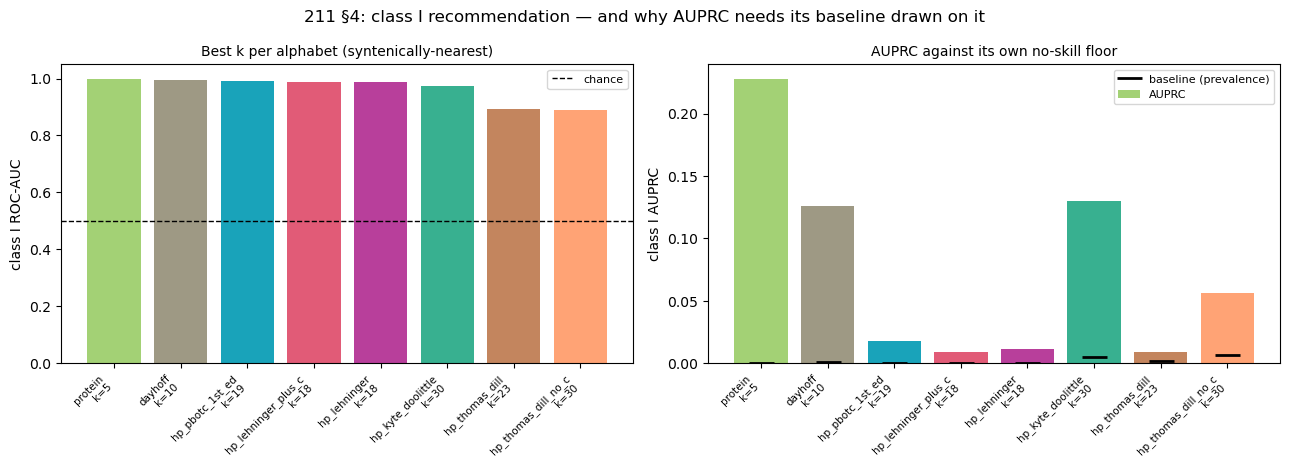

In [6]:
# Class II is the statistically solid half; class I is a stress test. Quantify that rather than
# asserting it: how tightly does each group's AUC sit across alphabets, under the headline policy?
for gname in GROUPS:
    s = auc_df.filter(
        (pl.col("group") == gname) & (pl.col("policy") == "synteny_nearest")
    )
    if s.height == 0:
        continue
    print(
        f"{gname:26s} n={s.height:3d} combos | ROC-AUC median {s['roc_auc'].median():.3f} "
        f"| IQR {s['roc_auc'].quantile(0.25):.3f}-{s['roc_auc'].quantile(0.75):.3f} "
        f"| min {s['roc_auc'].min():.3f} max {s['roc_auc'].max():.3f}"
    )

# Per-alphabet best, headline policy -- the actual recommendation table.
print(
    "\nBest ksize per alphabet (class I, syntenically-nearest), with its AUPRC baseline:"
)
ci_best = (
    auc_df.filter(
        (pl.col("group") == "class I (A/B/C/E/F/G)")
        & (pl.col("policy") == "synteny_nearest")
    )
    .sort("roc_auc", descending=True)
    .group_by("encoding", maintain_order=True)
    .first()
    .select(["encoding", "ksize", "roc_auc", "pr_auc", "prevalence", "n_pos"])
    .with_columns(
        pl.col("roc_auc").round(3),
        pl.col("pr_auc").round(3),
        pl.col("prevalence").round(4),
    )
    .sort("roc_auc", descending=True)
)
print(ci_best)

# Figure: the recommendation, with AUPRC shown against its own baseline rather than bare.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
lbl = [
    f"{ALPHABET_DISPLAY_NAMES.get(e, e)}\nk={k}"
    for e, k in zip(ci_best["encoding"], ci_best["ksize"])
]
x = np.arange(ci_best.height)

ax = axes[0]
ax.bar(
    x,
    ci_best["roc_auc"],
    color=[alphabet_color[e] for e in ci_best["encoding"]],
    alpha=0.9,
)
ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
ax.set_xticks(x)
ax.set_xticklabels(lbl, fontsize=7.5, rotation=45, ha="right")
ax.set_ylabel("class I ROC-AUC")
ax.set_ylim(0, 1.05)
ax.set_title("Best k per alphabet (syntenically-nearest)", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(
    x,
    ci_best["pr_auc"],
    color=[alphabet_color[e] for e in ci_best["encoding"]],
    alpha=0.9,
    label="AUPRC",
)
ax.plot(x, ci_best["prevalence"], "k_", ms=18, mew=2, label="baseline (prevalence)")
ax.set_xticks(x)
ax.set_xticklabels(lbl, fontsize=7.5, rotation=45, ha="right")
ax.set_ylabel("class I AUPRC")
ax.set_title("AUPRC against its own no-skill floor", fontsize=10)
ax.legend(fontsize=8)

fig.suptitle(
    "211 §4: class I recommendation — and why AUPRC needs its baseline drawn on it",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "211_class_i_recommendation.png", dpi=150, bbox_inches="tight")

auc_df.write_csv(RES / "211_mhc_auc_by_combo_policy.csv")
rec_df.write_csv(RES / "211_mhc_recovery_by_combo_policy.csv")
print(
    f"\nWrote 211_mhc_auc_by_combo_policy.csv ({auc_df.height:,} rows) and "
    f"211_mhc_recovery_by_combo_policy.csv ({rec_df.height:,} rows)"
)

## Verdict

**The label policy changes class I and leaves class II untouched, which is the benchmark's own
consistency check.** Class II's median ROC-AUC is 0.997 / 0.998 / 0.993 under `any_member` /
`best_scoring_member` / `synteny_nearest`; the policy is irrelevant there because those genes are
1:1. Class I's median moves 0.714 / **0.941** / 0.730 over the same three rules. Had the policy
moved class II as well, the synteny map would be suspect rather than the benchmark.

**`best_scoring_member` inflates class I by ~0.21 median ROC-AUC, and that gap is the size of the
circularity.** 0.941 vs 0.730 is not a better measurement; it is the same measurement allowed to
choose its own labels. Any published class I AUC that implicitly picked the best-matching partner
sits somewhere inside that 0.21.

**Policy choice flips the verdict for 18 of 62 combos.** For 29% of combos, "is this better than
chance?" gets a different answer depending on a rule nobody had previously written down. The median
paired shift is only −0.030, so the typical combo barely moves; the effect concentrates in the
combos whose class I signal was marginal to begin with.

**The 0.99 headline survives the stricter policy; its AUPRC does not.** `hp_pbotc_1st_ed_k19`
remains the best class I combo under `synteny_nearest` at ROC-AUC 0.990 (from 0.992). Its AUPRC
falls from 0.289 to **0.018**, against a baseline of 0.00025. That is still a ~71× lift over chance,
and it shows that a 0.99 ROC-AUC on a positive set of 6 against ~24k negatives is compatible with
very low precision. Quote both or neither.

**Class I recovery@1 for the classical genes drops to 0 under the syntenic policy** (from 0.333).
Kmerseek reliably finds *a* mouse class I gene as the top hit; it does not find the *syntenically
correct* one. That is the sharpest statement of what the one-to-many problem costs, and it matches
what notebook [215](./215_mhc_synteny_ground_truth.ipynb) sees from the other direction.

**The bits axis narrows the HP claim rather than confirming it.** "HP tolerates a wider k window"
was a units artifact. Each alphabet's own best point favors HP (hp_pbotc_1st_ed at 18.9 bits →
0.990 vs protein at 25.1 bits → 0.989), but those peaks sit at different budgets. At a **matched**
~25-bit budget, protein_k6 scores 0.989 while the best HP combo in that band reaches 0.839 and the
Lehninger variants fall to 0.30–0.37. **Protein wins at protein's own information budget.** The
supported claim is that HP reaches a comparable peak using less information per k-mer, not that HP
is the better encoding at equal information.

**Class II is the claim worth making; class I is a stress test whose direction is informative and
whose exact ordering is not.** Every alphabet degrades as k grows, the opposite of notebook 200's
genome-wide trend. That reversal is the substantive finding: the genome-wide leaderboard is the
wrong instrument for picking an encoding for a rapidly-evolving family. But with 4 effective
lineages behind each class I number, the ranking *among* the top alphabets (0.990 / 0.989 / 0.987 /
0.987) is not resolvable and should not be presented as one.

**Standing caveat carried forward.** An AUC is only as informative as its negative class, and the
negatives here are overwhelmingly mouse proteins with no structural relationship to MHC at all.
Notebooks [212](./212_mhc_domain_localisation.ipynb) and
[214](./214_mhc_igsf_specificity.ipynb) establish that the detected signal is substantially
Ig-scaffold-driven, so a high class I AUC is partly an "is this an immunoglobulin superfamily
protein" detector rather than purely an "is this the true MHC ortholog" detector. Read these numbers
as an upper bound on discriminative power until 214's negative controls are taken into account.